In [3]:
import pandas as pd
import numpy as np
import re
import nltk

In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') 

[nltk_data] Downloading package punkt to C:\Users\Basavaraj
[nltk_data]     M\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to C:\Users\Basavaraj
[nltk_data]     M\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [5]:
df = pd.read_csv("amazonreviews.tsv", sep='\t')
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [ ]:
print(df.shape)
print(df.info())

(10000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB
None


In [7]:
print(df.isnull().sum())

label     0
review    0
dtype: int64


In [9]:
df.duplicated().sum()

np.int64(0)

- there are no missing values and duplicate values in the data

In [10]:
stop_words = set(stopwords.words('english'))

In [12]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    words = word_tokenize(text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    # Join back
    return " ".join(words)

In [15]:
df['clean_review'] = df['review'].apply(clean_text)
df[['review','clean_review']].head()

,review,clean_review
0,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


The dataset was first inspected for duplicate and missing records. The review text was then preprocessed by converting all characters to lowercase, removing URLs, HTML tags, punctuation, and non-alphabetic characters. The cleaned text was tokenized into individual words, after which common English stopwords (such as "the", "is", and "and") were removed to retain only meaningful terms. The processed tokens were finally joined back into cleaned review strings, producing a normalized dataset suitable for feature extraction using techniques such as TF-IDF or Count Vectorization and subsequent sentiment classification.

In [21]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

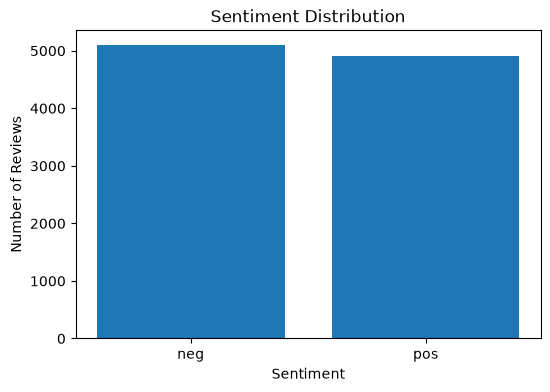

In [22]:
sentiment_counts = df['label'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [24]:
positive_reviews = " ".join(df[df['label'] == 'pos']['clean_review'])
negative_reviews = " ".join(df[df['label'] == 'neg']['clean_review'])

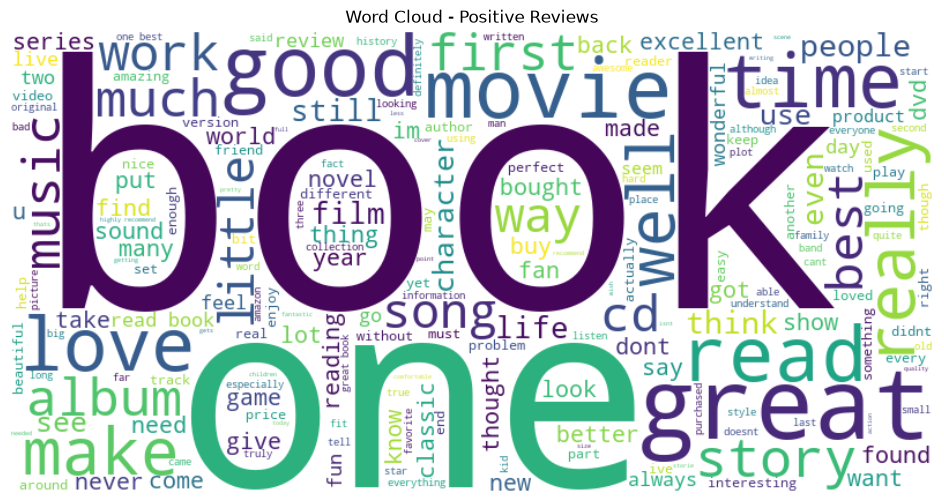

In [25]:
wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - Positive Reviews")
plt.show()

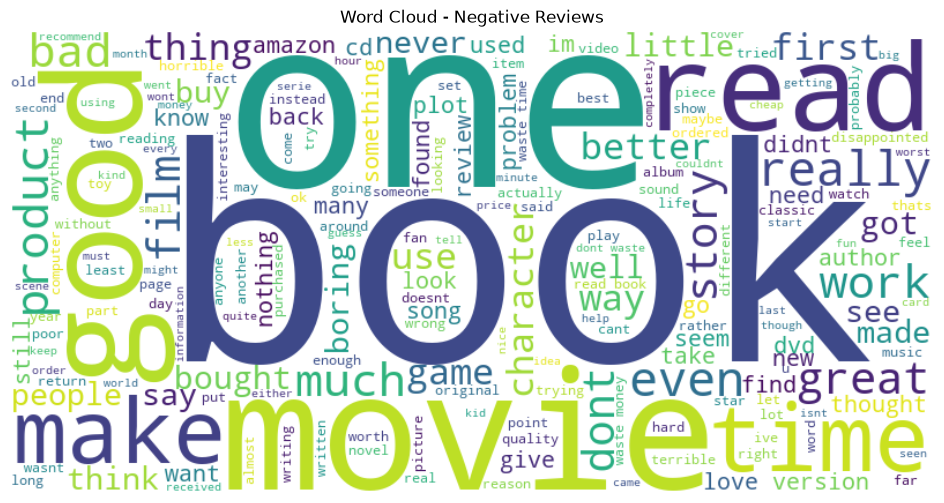

In [26]:
wordcloud_neg = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - Negative Reviews")
plt.show()

In [ ]:
positive_words = positive_reviews.split()
positive_counter = Counter(positive_words)
top_positive = positive_counter.most_common(20)
top_positive

[('book', 3313),
 ('great', 2087),
 ('one', 1835),
 ('good', 1635),
 ('read', 1553),
 ('like', 1268),
 ('movie', 1085),
 ('would', 943),
 ('love', 902),
 ('time', 871),
 ('well', 854),
 ('really', 827),
 ('best', 801),
 ('get', 793),
 ('story', 713),
 ('first', 708),
 ('much', 650),
 ('cd', 581),
 ('music', 559),
 ('also', 557)]

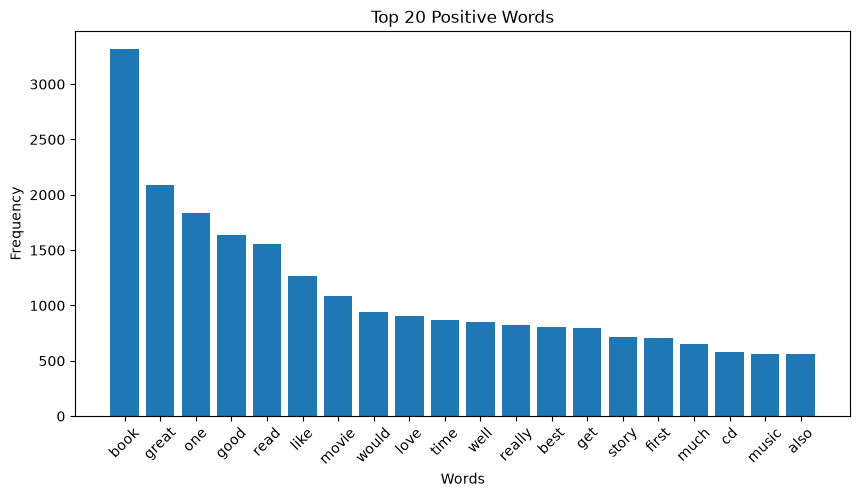

In [ ]:
words = [word for word, count in top_positive]
counts = [count for word, count in top_positive]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Positive Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [ ]:
negative_words = negative_reviews.split()
negative_counter = Counter(negative_words)
top_negative = negative_counter.most_common(20)
top_negative

[('book', 3184),
 ('one', 2022),
 ('like', 1547),
 ('movie', 1465),
 ('would', 1438),
 ('dont', 1240),
 ('read', 1187),
 ('get', 1139),
 ('good', 1134),
 ('time', 1034),
 ('even', 898),
 ('buy', 814),
 ('really', 778),
 ('much', 769),
 ('bad', 749),
 ('money', 744),
 ('first', 736),
 ('could', 658),
 ('better', 656),
 ('great', 632)]

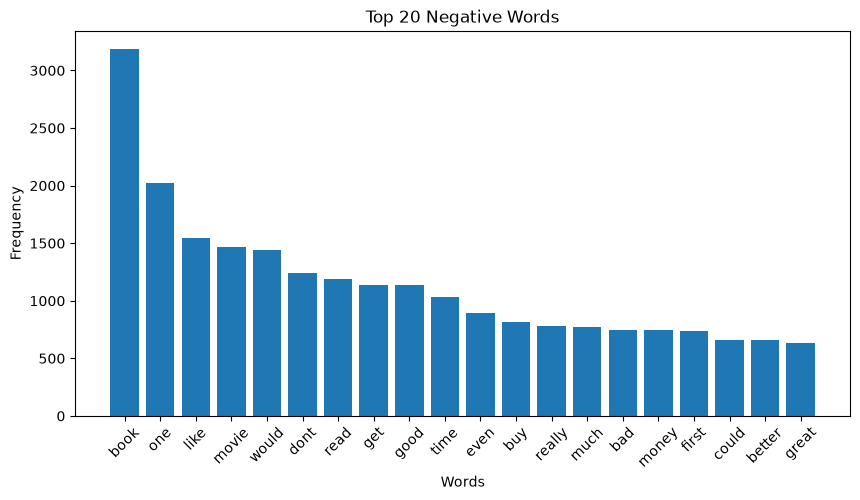

In [ ]:
words = [word for word, count in top_negative]
counts = [count for word, count in top_negative]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Negative Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

Exploratory Data Analysis (EDA) was performed to understand the distribution and characteristics of the review dataset. The sentiment distribution plot showed the number of positive and negative reviews, helping identify whether the dataset was balanced. Word clouds were generated separately for positive and negative reviews to visualize the most frequently occurring words in each sentiment category. Additionally, the top 20 most common words for both positive and negative reviews were identified using word frequency analysis and displayed using bar charts. These visualizations provide insights into the vocabulary associated with each sentiment class and help understand the textual patterns that the classification model is expected to learn.

#### Model Development

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [33]:
x = df['clean_review']
y = df['label']

In [34]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

In [37]:
model = LogisticRegression(random_state=42)

model.fit(x_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [38]:
y_pred = model.predict(x_test_tfidf)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8515

Classification Report

              precision    recall  f1-score   support

         neg       0.85      0.85      0.85      1019
         pos       0.85      0.85      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000


Confusion Matrix

[[870 149]
 [148 833]]


In [40]:
new_reviews = [
    "This product is amazing. I really loved it.",
    "Very poor quality and waste of money.",
    "The delivery was quick and the product works perfectly."
]

new_reviews_tfidf = tfidf.transform(new_reviews)

predictions = model.predict(new_reviews_tfidf)

for review, sentiment in zip(new_reviews, predictions):
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment}")
    print("-" * 50)

Review: This product is amazing. I really loved it.
Predicted Sentiment: pos
--------------------------------------------------
Review: Very poor quality and waste of money.
Predicted Sentiment: neg
--------------------------------------------------
Review: The delivery was quick and the product works perfectly.
Predicted Sentiment: pos
--------------------------------------------------


The cleaned review text was transformed into numerical feature vectors using the Term Frequency–Inverse Document Frequency (TF-IDF) technique. TF-IDF assigns higher importance to words that occur frequently in a review but are relatively rare across the entire dataset, making it effective for text classification tasks. The dataset was divided into training (80%) and testing (20%) sets while preserving the class distribution through stratified sampling. A Logistic Regression classifier was trained on the TF-IDF features to classify reviews as either positive or negative. Model performance was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. Additionally, a Linear Support Vector Machine (LinearSVC) model was implemented for comparison, as SVMs are well-suited for high-dimensional sparse text data generated by TF-IDF.